# Выбор региона для бурения нефтяных скважин

<a id='model555'></a>
## Ключевые выводы

**Задача:** Выбрать регион для бурения новых нефтяных скважин с максимальной ожидаемой прибылью при допустимом уровне риска убытков **не более 2.5%**.  
**Метод:** Построение модели линейной регрессии для прогноза запасов и оценка прибыли с помощью bootstrap.

### Результаты по регионам

| Регион | Ожидаемая средняя прибыль | Риск убытков (bootstrap) | Удовлетворяет условию? |
| :--- | :--- | :--- | :--- |
| Регион 1 | 425.9 млн руб. | **6.0%** | ❌ Нет |
| Регион 2 | **515.2 млн руб.** | **1.0%** | ✅ Да |
| Регион 3 | 435.0 млн руб. | **6.4%** | ❌ Нет |

**Единственный кандидат:**  
Регион №2 соответствует требованиям заказчика — риск убытков лишь **1.0%** при самой высокой ожидаемой прибыли **515.2 млн руб.** (95% доверительный интервал: от 68.9 млн до 931.5 млн руб.).

### ⚠️ Важное ограничение
Данные региона №2 содержат синтетическую аномалию: корреляция между признаком `f2` и целевым объёмом запасов составляет **0.999**, что физически невозможно.  
**Рекомендация:** запросить у заказчика уточнённые (не синтетические) данные по региону №2. В рамках учебного кейса формально выбрать регион №2.


## Содержание

- [Ключевые выводы](#model555)
- [Вступление](#model55)
- [Загрузка и подготовка данных](#model558)        
- [Обучение и проверка модели](#model557)
- [Подготовка к расчёту прибыли](#model5)
- [Расчёт прибыли и рисков](#model6)
- [Итоговые выводы](#model7)

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from pathlib import Path

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 10 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

<a id='model55'></a>
## Вступление

Нашей задачей является выбор региона для бурения скважин, согласно условиям заказчика - риск убытков в выбранном регионе должен быть минимален (не более 2,5%), а средняя ожидаемая прибыль должна быть наивысшей среди удовлетворяющих этому условию регионов. Моделирование должно производится через модель линейной регрессии.

Заказчик предоставил 3 сета данных для трех регионов. Обсудим план наших действий.

В работе мы: 
1. изучим и переработаем предоставленные данные
2. разобъем их на обучающую и валидационную выборки
3. обучим и исследуем модели линейной регрессии для выданных регионов
4. выберем лучшие скважины для бурения на основании модели
5. рассчитаем их среднюю прибыльность и доверительные интервалы прибыли для регионов
6. на основании этого дадим рекомендации по выборку удовлетворяющего условиям заказчика региона

<a id='model558'></a>
## Загрузка и подготовка данных

Загрузим данные:

In [2]:
data_path0 = Path.cwd().parent / 'data' / 'geo_data_0.csv'
data_path1 = Path.cwd().parent / 'data' / 'geo_data_1.csv'
data_path2 = Path.cwd().parent / 'data' / 'geo_data_2.csv'

raw_1 = pd.read_csv(data_path0)
raw_2 = pd.read_csv(data_path1)
raw_3 = pd.read_csv(data_path2)

Изучим данные, первый регион:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,id,f0,f1,f2,product
3551,XXcGn,1.495390,-0.324263,-2.623600,68.693072
22960,VIXGC,-1.009019,0.347689,3.484645,153.877396
54171,Kn58a,-0.947687,0.407970,7.245787,121.511821
9536,IvM0u,0.798088,-0.540431,7.328872,184.235035
9540,u2FlE,1.669935,-0.162437,-3.994298,24.001355


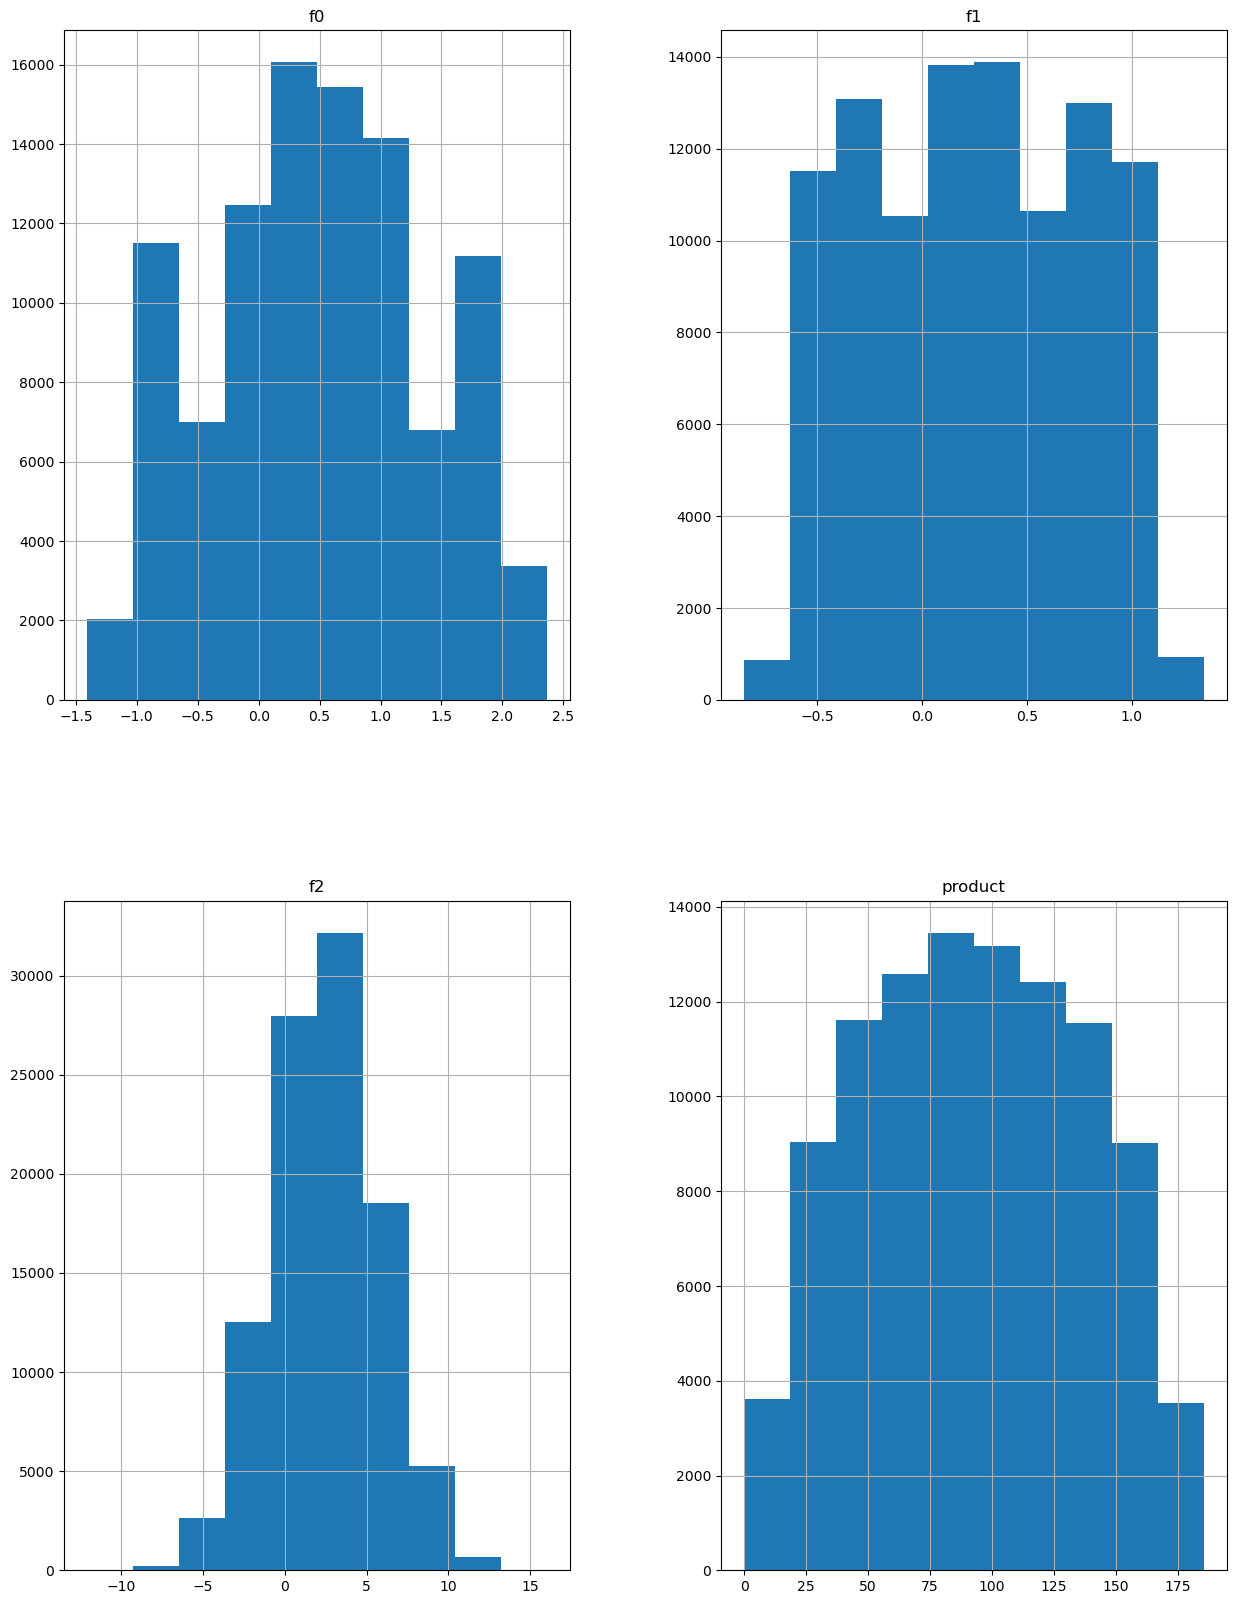

In [3]:
pd.set_option('display.max_columns', 50) 
# выводим обзорные данные о данных
raw_1.info()
display(raw_1.sample(5))
raw_1.hist(figsize=(15, 20))
None

Второй:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305
5,HHckp,-3.327590,-2.205276,3.003647,84.038886
6,h5Ujo,-11.142655,-10.133399,4.002382,110.992147
7,muH9x,4.234715,-0.001354,2.004588,53.906522
8,YiRkx,13.355129,-0.332068,4.998647,134.766305
9,jG6Gi,1.069227,-11.025667,4.997844,137.945408


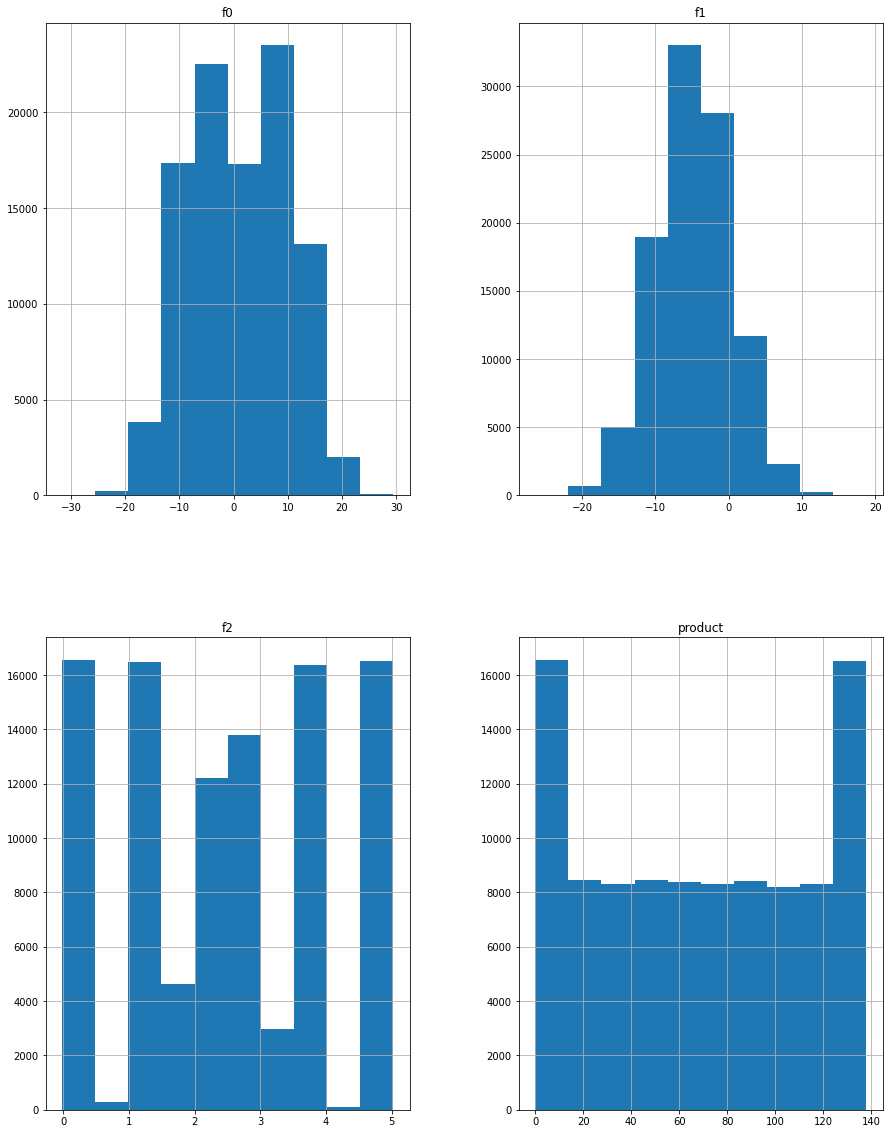

In [4]:
pd.set_option('display.max_columns', 50) 
# выводим обзорные данные о данных
raw_2.info()
display(raw_2.head(10))
raw_2.hist(figsize=(15, 20))
None

Третий:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746
5,LzZXx,-0.758092,0.710691,2.585887,90.222465
6,WBHRv,-0.574891,0.317727,1.773745,45.641478
7,XO8fn,-1.906649,-2.458350,-0.177097,72.480640
8,ybmQ5,1.776292,-0.279356,3.004156,106.616832
9,OilcN,-1.214452,-0.439314,5.922514,52.954532


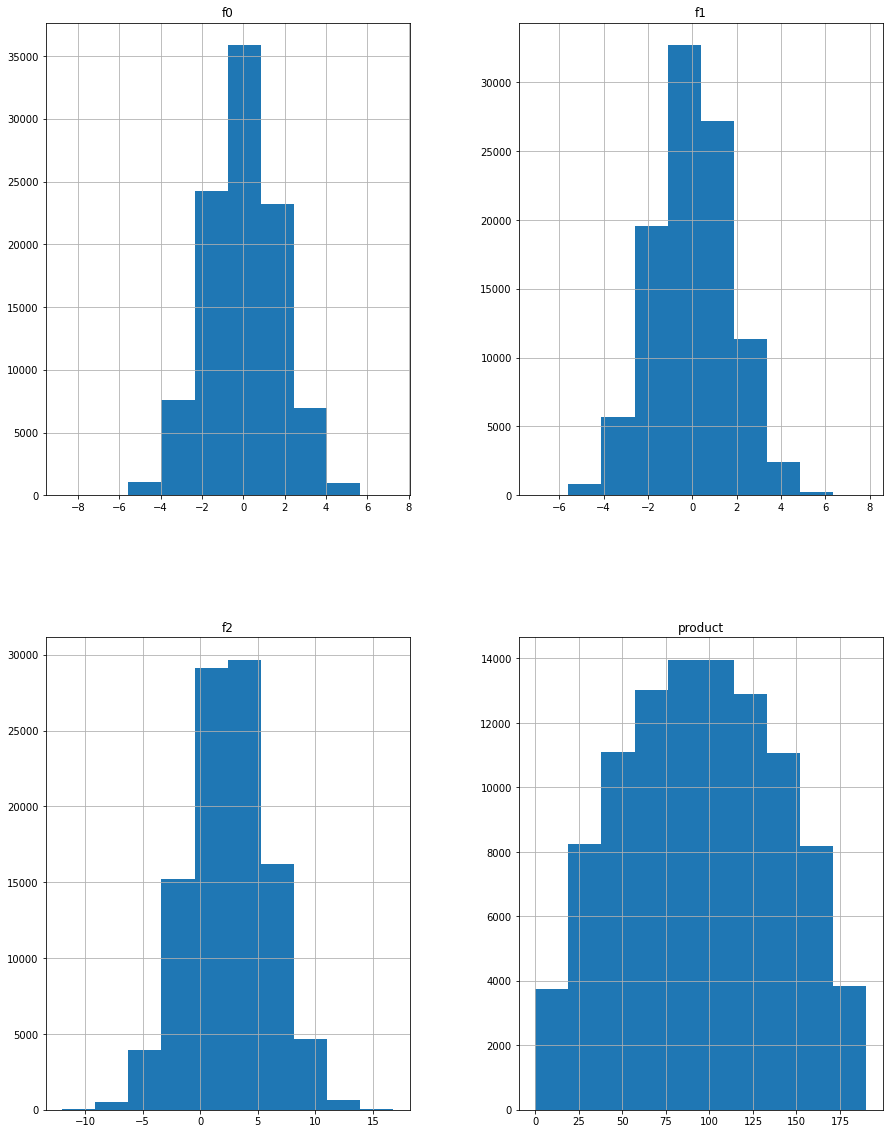

In [5]:
pd.set_option('display.max_columns', 50) 
# выводим обзорные данные о данных
raw_3.info()
raw_3.describe()
display(raw_3.head(10))
raw_3.hist(figsize=(15, 20))
None

С общего обзора особенно пока ничего не сказать. Посмотрим на статистические значения:

In [6]:
raw_1.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


In [7]:
raw_2.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


In [8]:
raw_3.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


Регион 2 выглядит сразу наиболее подозрительно в плане будущей добычи, в нем заметно сдвинуто распределение влево. Первый и третий выгледят очень похоже, в том числе и на графике. Большую ясность получим из построения моделей.

Проверим пропуски в данных:

In [9]:
for column_name in raw_1.columns:
    print(f'Пропусков в {column_name}:', raw_1[column_name].isna().sum())
# print чтобы переносов не было

Пропусков в id: 0
Пропусков в f0: 0
Пропусков в f1: 0
Пропусков в f2: 0
Пропусков в product: 0


In [10]:
for column_name in raw_1.columns:
    print(f'Пропусков в {column_name}:', raw_1[column_name].isna().sum())
# print чтобы переносов не было

Пропусков в id: 0
Пропусков в f0: 0
Пропусков в f1: 0
Пропусков в f2: 0
Пропусков в product: 0


In [11]:
for column_name in raw_1.columns:
    print(f'Пропусков в {column_name}:', raw_1[column_name].isna().sum())
# print чтобы переносов не было

Пропусков в id: 0
Пропусков в f0: 0
Пропусков в f1: 0
Пропусков в f2: 0
Пропусков в product: 0


Пропусков нет нигде. Последнее - столбцы id в файлах явно не потребуются при анализе, поэтому удалим их без особых сомнений:

In [12]:
raw_1.drop('id', axis=1, inplace=True)
raw_2.drop('id', axis=1, inplace=True)
raw_3.drop('id', axis=1, inplace=True)

<a id='model557'></a>
## Обучение и проверка модели

### Разбиение данных на выборки

Разделим данные на целевой признак и остальное:

In [13]:
features_1 = raw_1.drop('product', axis=1)
target_1 = raw_1['product']
features_2 = raw_2.drop('product', axis=1)
target_2 = raw_2['product']
features_3 = raw_3.drop('product', axis=1)
target_3 = raw_3['product']

Затем на тренировочные и валидационные в соотношении 3 к 1:

In [14]:
features_train_1, features_valid_1, target_train_1, target_valid_1 = \
train_test_split(features_1, target_1, test_size=0.25, random_state=12345)
features_train_2, features_valid_2, target_train_2, target_valid_2 = \
train_test_split(features_2, target_2, test_size=0.25, random_state=12345)
features_train_3, features_valid_3, target_train_3, target_valid_3 = \
train_test_split(features_3, target_3, test_size=0.25, random_state=12345)
display('Размеры тренировочных данных и целового признака', features_train_1.shape, target_train_1.shape)
display('Размеры валидационных данных и целового признака', features_valid_1.shape, target_valid_1.shape)

'Размеры тренировочных данных и целового признака'

(75000, 3)

(75000,)

'Размеры валидационных данных и целового признака'

(25000, 3)

(25000,)

### Моделирование запасов регионов через регрессию

В рамках задачи мы используем только модель линейной регрессии, поэтому обучим ее отдельно для каждого региона:

In [15]:
model = LinearRegression()
# первый регион
model.fit(features_train_1, target_train_1)
model_score_1 = cross_val_score(model, features_train_1, target_train_1, cv=5)
predicted_valid_1 = model.predict(features_valid_1)
# Средние предсказанные запасы для региона 1:
av_oil_likely_1 = np.mean(predicted_valid_1)
# Корень из средней квадратичной ошибки для региона 1: 
rmse_1 = mean_squared_error(target_valid_1, predicted_valid_1)** 0.5
display('Средние предсказанные запасы для региона 1:', av_oil_likely_1)
display('Средний R-квадрат для региона 1:', sum(model_score_1)/len(model_score_1))
display('Корень из средней квадратичной ошибки для региона 1:', rmse_1)
# второй регион
model.fit(features_train_2, target_train_2)
model_score_2 = cross_val_score(model, features_train_2, target_train_2, cv=5)
predicted_valid_2 = model.predict(features_valid_2)
# Средние предсказанные запасы для региона 2:
av_oil_likely_2 = np.mean(predicted_valid_2)
# Корень из средней квадратичной ошибки для региона 2: 
rmse_2 = mean_squared_error(target_valid_2, predicted_valid_2)** 0.5
display('Средние предсказанные запасы для региона 2:', av_oil_likely_2)
display('Средний R-квадрат для региона 2:', sum(model_score_2)/len(model_score_2))
display('Корень из средней квадратичной ошибки для региона 2:', rmse_2)
# третий регион
model.fit(features_train_3, target_train_3)
model_score_3 = cross_val_score(model, features_train_3, target_train_3, cv=5)
predicted_valid_3 = model.predict(features_valid_3)
# Средние предсказанные запасы для региона 3:
av_oil_likely_3 = np.mean(predicted_valid_3)
# Корень из средней квадратичной ошибки для региона 3: 
rmse_3 = mean_squared_error(target_valid_3, predicted_valid_3)** 0.5
display('Средние предсказанные запасы для региона 3:', av_oil_likely_3)
display('Средний R-квадрат для региона 3:', sum(model_score_3)/len(model_score_3))
display('Корень из средней квадратичной ошибки для региона 3:', rmse_3)

'Средние предсказанные запасы для региона 1:'

92.59256778438035

'Средний R-квадрат для региона 1:'

0.27408653371000735

'Корень из средней квадратичной ошибки для региона 1:'

...

94.96504596800489

'Средний R-квадрат для региона 3:'

0.19648225543040274

'Корень из средней квадратичной ошибки для региона 3:'

40.02970873393434

Для второго региона, регрессия потрясающе хорошо описывает запасы. Это сразу делает, в рамках задачи, регион привлекательным, но стоит помнить, что вообще говоря, у нас и так есть данные для точного расчета прибыли во всех регионах, а при расширении модели на новые регионы, фантастическая точность вряд ли сохранится (см. регионы 1 и 3). Тем не менее, в рамках текущей задачи, регион 2 чудом сильно вырвался вперед.

Стоп, вообще говоря, такой r-2 означает гипер-корреляцию между зависимой величиной и признаками. Проверим:

In [16]:
display('Корреляции для первого региона:', raw_1.corr())
display('Корреляции для второго региона:', raw_2.corr())
display('Корреляции для третьего региона:', raw_3.corr())

'Корреляции для первого региона:'

,f0,f1,f2,product
f0,1.000000,-0.440723,-0.003153,0.143536
f1,-0.440723,1.000000,0.001724,-0.192356
f2,-0.003153,0.001724,1.000000,0.483663
product,0.143536,-0.192356,0.483663,1.000000


'Корреляции для второго региона:'

,f0,f1,f2,product
f0,1.000000,0.182287,-0.001777,-0.030491
f1,0.182287,1.000000,-0.002595,-0.010155
f2,-0.001777,-0.002595,1.000000,0.999397
product,-0.030491,-0.010155,0.999397,1.000000


'Корреляции для третьего региона:'

,f0,f1,f2,product
f0,1.000000,0.000528,-0.000448,-0.001987
f1,0.000528,1.000000,0.000779,-0.001012
f2,-0.000448,0.000779,1.000000,0.445871
product,-0.001987,-0.001012,0.445871,1.000000


А, нам просто прислали во втором регионе output вместо f2. Вообще говоря, в этом месте нужно связаться с заказчиком и допросить его насчет правильности данных для региона 2. Маловероятно, что геологи из региона 2 изобрели способ определять запасы с вероятностью 99,93% по вторичному признаку, хотя поздравим их, если это так.

Итак, одна стратегия состояла бы в том, чтобы не обсчитывать регион 2, а ждать уточненных данных от заказчика. Можно также попробовать исключить столбец f2, и осмотреть регрессию снова, что мы сделаем ниже.

По другим регионам, есть корреляция, но в пределах приличия, в реальных данных такое безобразие встречаем повсеместно. Отбрасываем f2 в регионе 2:

In [17]:
features_2_cleaned = raw_2.drop(['f2','product'], axis=1)
features_train_2_cl, features_valid_2_cl, target_train_2, target_valid_2 = \
train_test_split(features_2_cleaned, target_2, test_size=0.25, random_state=12345)
# второй регион
model.fit(features_train_2_cl, target_train_2)
model_score_2_cl = cross_val_score(model, features_train_2_cl, target_train_2, cv=5)
predicted_valid_2_cl = model.predict(features_valid_2_cl)
# Средние предсказанные запасы для региона 2:
av_oil_likely_2_cl = np.mean(predicted_valid_2_cl)
# Корень из средней квадратичной ошибки для региона 2: 
rmse_2_cl = mean_squared_error(target_valid_2, predicted_valid_2_cl)** 0.5
display('Средние предсказанные запасы для региона 2:', av_oil_likely_2_cl)
display('Средний R-квадрат для региона 2:', sum(model_score_2_cl)/len(model_score_2_cl))
display('Корень из средней квадратичной ошибки для региона 2:', rmse_2_cl)

'Средние предсказанные запасы для региона 2:'

68.85899112906348

'Средний R-квадрат для региона 2:'

0.0008864417079933018

'Корень из средней квадратичной ошибки для региона 2:'

46.006958160915644

И-и-и-и, теперь модель для региона 2 полностью бесполезна. С таким R-squared регрессия не поясняет ничего, предсказывать на ее основе можно ничего, бесмысленно, лучше будет, если мы работаем со средним по региону.

В связи с этим, мы делаем волюнтаристское решение - оставить модель с для региона с неудаленным столбцом 2 для того, чтобы, когда придут данные от заказчика, быстро, на основании новых данных, пересчитать все и получить уже полные результаты. Однако, из выводов регион 2 как регион с испорченными данными (или, альтернативно, как регион с недостаточными для анализа данными) мы удалим и сосредоточимся далее, до ответа заказчика, на регионах 1 и 3.

### Краткий итог

Мы разделили данные по запасам на тренировочную и валидационную часть и обучили простейшую модель линейной регрессии отдельно для каждого из регионов. Регионы 1 и 3 ожидаемо посредственно описываются регрессией, с низким r-квадратом. Регион 2 представляет собой, либо чудо природы, либо синтетические данные и полностью описывается линейной регрессией из-за того, что столбец f2 в нем почти идентичен столбцу output. Строить регрессию с таким столбцом нельзя - физически же, если хочется прогнозировать запасы в регионе 2, у заказчика есть для этого столбец f2. Исключение f2 из регрессии в регионе 2 обедняет данные, приводя r-квадрат почти к нулю, и делая построение регрессии бесмысленной. Мы считаем, что в такой ситуации нужно запросить заказчика по корректным данным, а пока технически продолжим расчеты в регионе 2, чтобы можно было быстро получить результаты по приходу корректных данных, но включать его в выводы и реальный анализ не будем.

Однако, по результатам запроса заказчика, оказалось, что это учебно-синтетические данные, поэтому дальше мы не будем убирать их из рассмотрения и включим в дальнейшие выводы.

<a id='model5'></a>
## Подготовка к расчёту прибыли

### Условия для расчета прибыли

Прежде всего, запишем условия задачи для расчета прибыльности:

In [18]:
# Общий бюджет на разработку
budget = 10*(10**9)
# удельная прибыль со скважины
borehole_profit = 450000
# Максимальное число разрабатываемых скважин в регионе
boreholes_max = 200
# Всего скважин в регионе
boreholes_total = 500
# Максимальные расходы на скважину
borehole_cost = budget / boreholes_max
# максимально допустимый риск убытка всей операции
max_risk = 0.025

Потренируемся в арифметике и рассчитаем средний запас сырья, нужный для безубыточной разработки региона и скважины:

In [19]:
zero_prod = budget/borehole_profit
display('Минимальные извлеченные запасы для точки безубыточности', '{:.1f}'.format(zero_prod))
zero_prod_borehole = zero_prod/boreholes_max
display('Средние извлеченные запасы с одной скважины для точки безубыточности', '{:.1f}'.format(zero_prod_borehole))

'Минимальные извлеченные запасы для точки безубыточности'

'22222.2'

'Средние извлеченные запасы с одной скважины для точки безубыточности'

'111.1'

Вспоминая реальные средние показатели регионов из части 1 работы, а именно 92,5, 68,825, 95 для трех регионов соотвественно, понимаем, что действительно нужно будет выбрать наилучшие 200 скважин, и что риск убытков есть.

### Выбор скважин на основании предсказаний регрессии

Поскольку в реальной задаче, мы, видимо, знаем характеристики скважины, но не знаем истинные ее запасы, далее мы будем ориентироваться на результаты расчетов модели, а не на представленные в столбцах product запасы. Составляем новые таблицы о регионах с предсказанными запасами:

In [20]:
predicted_1 = pd.DataFrame(predicted_valid_1, index=features_valid_1.index, columns=['pred_out'])
predicted_2 = pd.DataFrame(predicted_valid_2, index=features_valid_2.index, columns=['pred_out'])
predicted_3 = pd.DataFrame(predicted_valid_3, index=features_valid_3.index, columns=['pred_out'])
predicted_1.head()

,pred_out
71751,95.894952
80493,77.572583
2655,77.892640
53233,90.175134
91141,70.510088


В каждом регионе выбираем лучшее (по мнению регрессии) 200 скважин и считаем для них средние:

In [21]:
reg_1_200_best = predicted_1.sort_values(by='pred_out', ascending=False)[:boreholes_max]
reg_2_200_best = predicted_2.sort_values(by='pred_out', ascending=False)[:boreholes_max]
reg_3_200_best = predicted_3.sort_values(by='pred_out', ascending=False)[:boreholes_max]
display('Средние запасы в лучших 200 скважинах для региона 1', reg_1_200_best.mean())
display('Средние запасы в лучших 200 скважинах для региона 2', reg_2_200_best.mean())
display('Средние запасы в лучших 200 скважинах для региона 3', reg_3_200_best.mean())

'Средние запасы в лучших 200 скважинах для региона 1'

pred_out    155.511654
dtype: float64

'Средние запасы в лучших 200 скважинах для региона 2'

pred_out    138.730134
dtype: float64

'Средние запасы в лучших 200 скважинах для региона 3'

pred_out    148.019493
dtype: float64

Везде выглядит не безнадежно. Вспомним показатели истинных данных:

In [22]:
reg_1_200_best_real = raw_1.sort_values(by='product', ascending=False)[:boreholes_max]['product']
reg_2_200_best_real = raw_2.sort_values(by='product', ascending=False)[:boreholes_max]['product']
reg_3_200_best_real = raw_3.sort_values(by='product', ascending=False)[:boreholes_max]['product']
display('Средние истинные запасы в лучших 200 скважинах для региона 1', reg_1_200_best_real.mean())
display('Средние истинные запасы в лучших 200 скважинах для региона 2', reg_2_200_best_real.mean())
display('Средние истинные запасы в лучших 200 скважинах для региона 3', reg_3_200_best_real.mean())

'Средние истинные запасы в лучших 200 скважинах для региона 1'

184.83373964536008

'Средние истинные запасы в лучших 200 скважинах для региона 2'

137.9454077409057

'Средние истинные запасы в лучших 200 скважинах для региона 3'

189.55147698176646

Тоже хорошо.

### Краткий итог

Все три региона предварительно в среднем удовлетворяют точке безубыточности, находящейся на значении 111 тысяч баррелей на скважину (по модулю второго - там данные не надежны). Данные для расчетов введены, можно приступать к расчетам прибыли.

<a id='model6'></a>
## Расчёт прибыли и рисков 

### Расчет ожидаемой согласно регрессии прибыли

Начнем с подсчета общей прибыли в регионе. Составим примитивную функцию для расчета реальных значений прибыли от 200 скважин, которые регрессия считает лучшими:

In [23]:
def profit(predict, actual):
    # сортируем предсказанные моделью значения, выбирая лучшие 200:
    probs_sorted = predict.sort_values(ascending=False)
    # применяем эту сортировку к реальным значениям запасов, выбирая лучшие по мнению регрессии 200:
    selected = actual[probs_sorted.index][:boreholes_max]
    # собственно считаем с них прибыль:
    profit = selected.sum() * borehole_profit - budget
    return profit

Рассчитаем прибыль для каждого региона:

In [24]:
display('Реальная общая прибыль на 200 лучших скважинах в регионе 1:', profit(reg_1_200_best['pred_out'], target_valid_1))
display('Реальная общая прибыль на 200 лучших скважинах в регионе 2:',profit(reg_2_200_best['pred_out'], target_valid_2))
display('Реальная общая прибыль на 200 лучших скважинах в регионе 3:',profit(reg_3_200_best['pred_out'], target_valid_3))

'Реальная общая прибыль на 200 лучших скважинах в регионе 1:'

3320826043.1398506

'Реальная общая прибыль на 200 лучших скважинах в регионе 2:'

2415086696.681511

'Реальная общая прибыль на 200 лучших скважинах в регионе 3:'

2710349963.5998325

Регион 2 не учитываем в выводах, регионы 1 и 3 выглядят неплохо. Это, если что я так понял фразу "Просуммируйте *целевое* значение объёма сырья, соответствующее этим предсказаниям". Если мы хотим подсчитать просто предсказанные моделью запасы, то это проще:

In [25]:
def predicted_profit(predicted):
    turnover = np.sum(predicted) * borehole_profit
    profit = turnover - budget
    return profit

Рассчитаем ожидаемую прибыль для каждого региона:

In [26]:
display('Ожидаемая общая прибыль на 200 лучших скважинах в регионе 1:',predicted_profit(reg_1_200_best['pred_out']))
display('Ожидаемая общая прибыль на 200 лучших скважинах в регионе 2:',predicted_profit(reg_2_200_best['pred_out']))
display('Ожидаемая общая прибыль на 200 лучших скважинах в регионе 3:',predicted_profit(reg_3_200_best['pred_out']))

'Ожидаемая общая прибыль на 200 лучших скважинах в регионе 1:'

3996048877.46513

'Ожидаемая общая прибыль на 200 лучших скважинах в регионе 2:'

2485712051.9735413

'Ожидаемая общая прибыль на 200 лучших скважинах в регионе 3:'

3321754396.2432556

Намного оптимистичней. Регион 2 традиционно игнорируем. Согласно эпически точной регрессии с r-квадратом под 20% нас ожидают золотые горы как в регионе 1, так и 3.

### Расчет доверительных интервалов для модели

Теперь расчитаем доверительные интервалы для трех регионов через bootstrap  с 1000 выборок:

In [27]:
reg_1_pred = pd.Series(predicted_1['pred_out'])
reg_2_pred = pd.Series(predicted_2['pred_out'])
reg_3_pred = pd.Series(predicted_3['pred_out'])

# вычисляем интервал как в тренажере
def confidence_interval(predicted, actual):
    state = np.random.RandomState(12345)
    samples = []
    for i in range(1000):
        subsample = actual.sample(n=boreholes_total, replace=True, random_state=state)
        pred_subsample = predicted[subsample.index]
        samples.append(profit(pred_subsample, subsample))
        
    samples = pd.Series(samples)
    mean = samples.mean()
    loss = samples[samples < 0]
    lower = samples.quantile(0.025)
    upper = samples.quantile(0.975)
    print('Среднее значение, вычисленное через bootstrap:', round(mean,0))
    print('2,5% квантиль доверительного интервала:', round(lower,0))
    print('97,5% квантиль доверительного интервала:', round(upper,0))  
    print('Вероятность убытков, оцененная через bootstrap:', len(loss)*100/1000, '%')
    return  round(mean,0), round(lower,0), round(upper,0)

In [28]:
display(reg_1_pred.head(), target_valid_1.head())

71751    95.894952
80493    77.572583
2655     77.892640
53233    90.175134
91141    70.510088
Name: pred_out, dtype: float64

71751     10.038645
80493    114.551489
2655     132.603635
53233    169.072125
91141    122.325180
Name: product, dtype: float64

Применим расчеты доверительного интервала к трем регионам:

In [29]:
display('Доверительный интервал для прибыли в первом регионе:')
confidence_interval(reg_1_pred, target_valid_1)
display('Доверительный интервал для прибыли во втором регионе:')
confidence_interval(reg_2_pred, target_valid_2)
display('Доверительный интервал для прибыли в третьем регионе:')
confidence_interval(reg_3_pred, target_valid_3)

'Доверительный интервал для прибыли в первом регионе:'

Среднее значение, вычисленное через bootstrap: 425938527.0
2,5% квантиль доверительного интервала: -102090095.0
97,5% квантиль доверительного интервала: 947976353.0
Вероятность убытков, оцененная через bootstrap: 6.0 %


'Доверительный интервал для прибыли во втором регионе:'

Среднее значение, вычисленное через bootstrap: 515222773.0
2,5% квантиль доверительного интервала: 68873225.0
97,5% квантиль доверительного интервала: 931547591.0
Вероятность убытков, оцененная через bootstrap: 1.0 %


'Доверительный интервал для прибыли в третьем регионе:'

Среднее значение, вычисленное через bootstrap: 435008363.0
2,5% квантиль доверительного интервала: -128880547.0
97,5% квантиль доверительного интервала: 969706954.0
Вероятность убытков, оцененная через bootstrap: 6.4 %


(435008363.0, -128880547.0, 969706954.0)

На основании вычислений через bootstrap, мы уже можем составлять финальную рекомендацию для заказчика. Согласно его правилам, вероятность убытков не должна превышать 2,5% (т.е. нижняя 2,5% квантиль должна быть выше нуля), а если первое условие выполнено, то выбрать регион с наибольшей средней прибылью. Ответим в итоговых выводах.

### Рекомендации по выбору региона

На основании анализа прибыли регионов и bootstrap анализа доверительного интервала, мы предоставляем заказчику следующие рекомендации - переслать данные по региону 2 без ошибки, чтобы можно было закончить анализ. Все остальные регионы не удовлнтворяют требованиям заказчика по минимизации риска (2,5% квантиль доверительного интервала: -128880547 в третьем регионе и 2,5% квантиль доверительного интервала: -102090095 в первом регионе). Игнорируя же синтетическую природу данных в регионе 2, мы приходим к выводу, что он единственный удовлетворяет условиям заказчика, и разработка должна вестись именно в нем. 

Другие регионы предоставляют как худшую среднюю прибыль, так и более высокий риск убытков.

<a id='model7'></a>
## Итоговые выводы 

Мы провели исследование и составление модели для данных о регионах, в которых потенциально возможно бурение с целью получения прибыли от добычи нефти. <br>

Нашей задачей было построить модель, на основании этих характеристик прогнозирующую прибыльность разработки региона. Условиями заказчика было - минимализация риска - не более 2,5% риска убытка согласно модели + выбор из удовлетворяющих этому условию региона с максимальной прибылью. <br>

Работа по составлению рекомендаций состояла из следующих шагов:
<ol>
<li>Очищение и изучение данных - удаление пропусков, поиск дисбалансов и т.д.</li>
<li>Исследование линейной регрессии в трех предложенных регионах.</li>
<li>Вычисление прибыли согласно модели во всех регионах.</li>
<li>НаНа основании модели построение ожидаемой приыбли, доверительных интервалов для нее и выдача рекомендаций</li>    
</ol>

Исключая синтетическую природу данных региона 2, только этот регион удовлетворяет условиям заказчика:

In [30]:
display('Доверительный интервал для прибыли в первом регионе:')
confidence_interval(reg_1_pred, target_valid_1)
display('Доверительный интервал для прибыли во втором регионе:')
confidence_interval(reg_2_pred, target_valid_2)
display('Доверительный интервал для прибыли в третьем регионе:')
confidence_interval(reg_3_pred, target_valid_3)

'Доверительный интервал для прибыли в первом регионе:'

Среднее значение, вычисленное через bootstrap: 425938527.0
2,5% квантиль доверительного интервала: -102090095.0
97,5% квантиль доверительного интервала: 947976353.0
Вероятность убытков, оцененная через bootstrap: 6.0 %


'Доверительный интервал для прибыли во втором регионе:'

Среднее значение, вычисленное через bootstrap: 515222773.0
2,5% квантиль доверительного интервала: 68873225.0
97,5% квантиль доверительного интервала: 931547591.0
Вероятность убытков, оцененная через bootstrap: 1.0 %


'Доверительный интервал для прибыли в третьем регионе:'

Среднее значение, вычисленное через bootstrap: 435008363.0
2,5% квантиль доверительного интервала: -128880547.0
97,5% квантиль доверительного интервала: 969706954.0
Вероятность убытков, оцененная через bootstrap: 6.4 %


(435008363.0, -128880547.0, 969706954.0)

Первый и третий регион, согласно модели, допускают вероятность убытков от разработки, превосходящую 2,5%. А второй регион на представленных данных и удовлетворяет требованиям заказчика, хотя его данные содержат очевидные артефакты, а именно:

In [31]:
display('Корреляции для второго региона:', raw_2.corr())

'Корреляции для второго региона:'

,f0,f1,f2,product
f0,1.000000,0.182287,-0.001777,-0.030491
f1,0.182287,1.000000,-0.002595,-0.010155
f2,-0.001777,-0.002595,1.000000,0.999397
product,-0.030491,-0.010155,0.999397,1.000000


Его столбец f2 почти полностью скоррелирован со столбцом product, что физически невозможно.

В итоге, мы либо просим заказчика переслать уточненные данные по региону 2 для окончательных выводов. Либо, трактуя задание как учебное и не заботясь о синтетической природе данных, рекомендуем единственный регион для разработки - регион 2, отвечающий всем требованиям заказчика.